
# <font color='#F5B167'> MD009 Comprobación generador de números aleatorios </font>

Comprobemos si el generador de números aleatorios que usamos en R nos proporciona realmente una distribución uniforme.
Generemos 10000 números aleatorios y apliquemos un test de $\chi^2$.

In [1]:
u10k <- runif(10000)

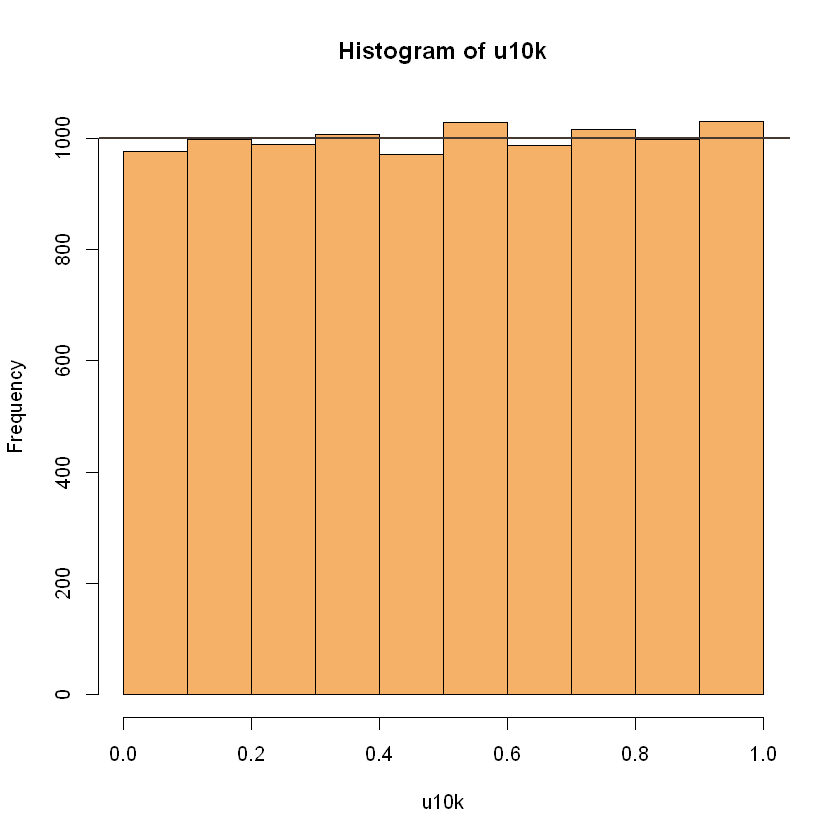

In [2]:
histv <- hist(u10k, breaks = 10, col = '#F5B167')
abline(h = 1000, col = '#463932', lw = 2)

In [3]:
observed = histv$counts
observed

[1]  976  998  989 1007  971 1028  987 1016  998 1030

In [4]:
expected = c(0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1)
result1 <- chisq.test(x = histv$counts, p = expected)
result1
result1$expected


	Chi-squared test for given probabilities

data:  histv$counts
X-squared = 3.704, df = 9, p-value = 0.9298


[1] 1000 1000 1000 1000 1000 1000 1000 1000 1000 1000

En este caso pasa el test de $\chi^2$. Para $\alpha=0.05$ y 9 grados de libertad (10 bines - 1), el valor crítico sería $\chi^2=16.92$. Como el valor obtenido del test es menor, aceptamos el resultado como válido.

¿Qué pasa en el caso de generar menos puntos? Por ejemplo 100.


	Chi-squared test for given probabilities

data:  histv2$counts
X-squared = 13.2, df = 9, p-value = 0.1538


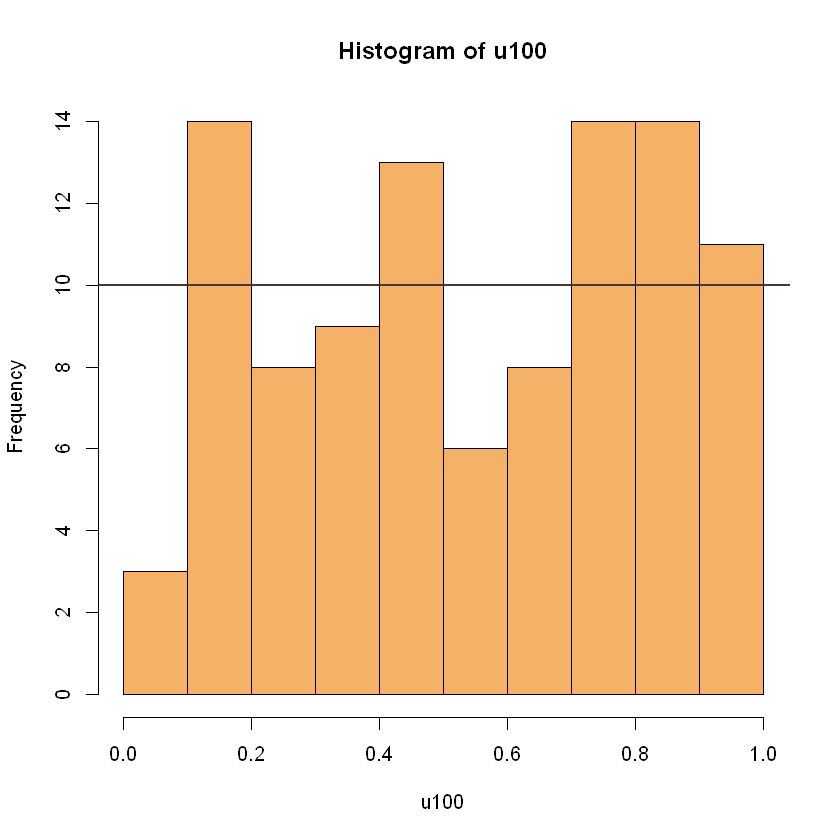

In [5]:
u100 <- runif(100)
histv2 <- hist(u100, breaks = 10, col = '#F5B167')
abline(h = 10, col = '#463932', lw = 2)
chisq.test(x = histv2$counts, p = expected)

Todavía pasa el test de $\chi^2$.

También podemos probar el test de Kolmogorov-Smirnov.

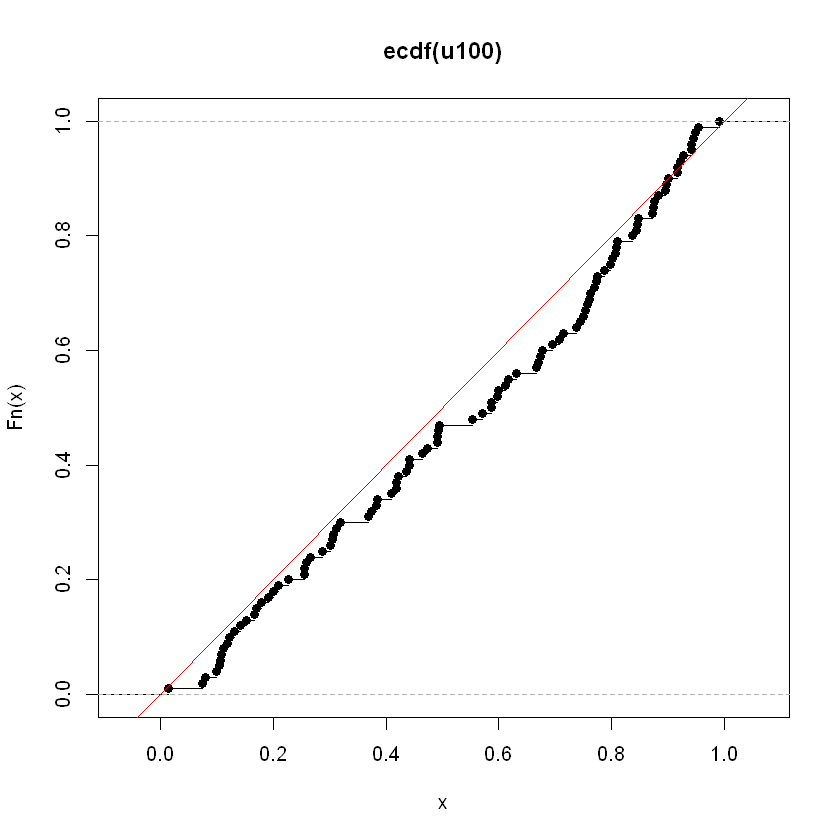

In [6]:
plot(ecdf(u100))
abline(0, 1, col = "red")

In [7]:
ks.test(u100, "punif")


	One-sample Kolmogorov-Smirnov test

data:  u100
D = 0.10783, p-value = 0.1953
alternative hypothesis: two-sided


Donde el valor crítico viene dado por $D_{n, \alpha}=1.3581/\sqrt{n}$. Para $n=100$ y $\alpha=0.05$, sería $0.1358$, por tanto, la muestra pasa el test de uniformidad.  

Para la muestra de 10000 números:

In [8]:
ks.test(u10k, "punif")


	One-sample Kolmogorov-Smirnov test

data:  u10k
D = 0.007947, p-value = 0.5528
alternative hypothesis: two-sided


En este caso, el valor crítico es $0.0136$, por encima del valor obtenido. 

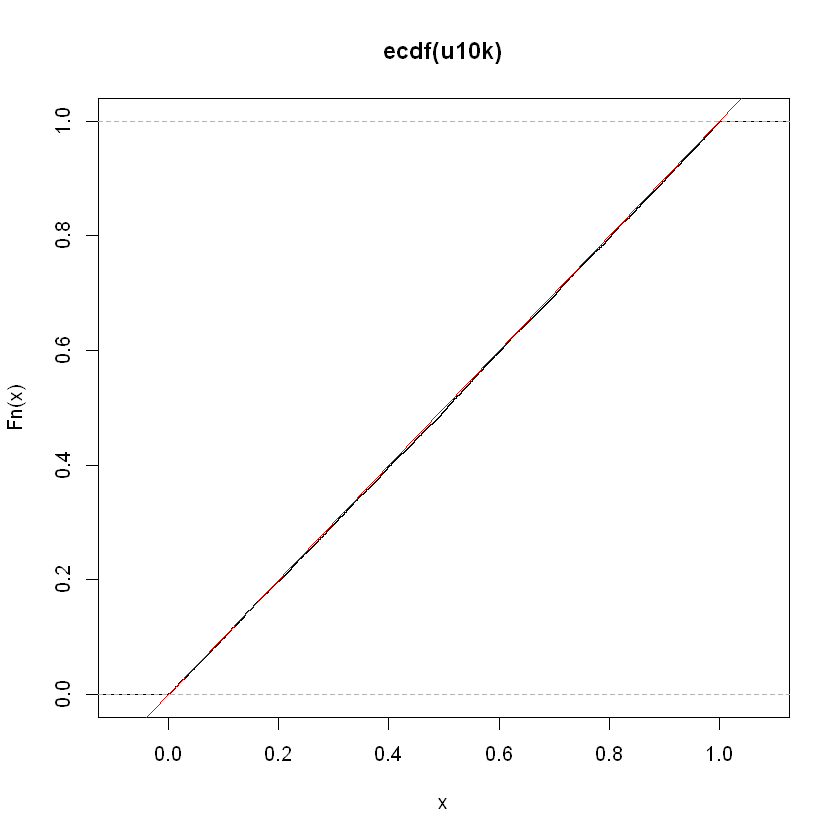

In [9]:
plot(ecdf(u10k))
abline(0, 1, col = "red")

Comprobemos que no hay autocorrelación dibujando los pares $(u_i, u_{i+1})$ para una muestra de 1000 números (para una mejor visualización).

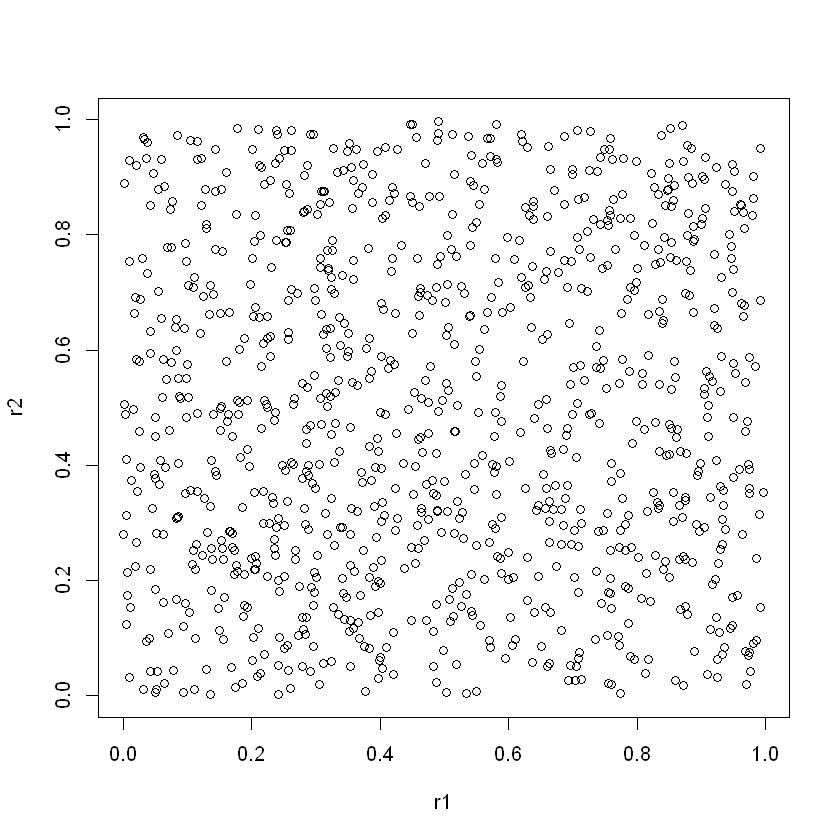

In [10]:
u1k <- runif(1000)
r1 = u1k[-1000]
r2 = u1k[-1]
plot(r1, r2)